In [53]:
from common import *
n = 2

# Build

In [13]:
a = QuantumRegister(2, name="A")
b = QuantumRegister(2, name="B")
s = QuantumRegister(3, name="S")

[Optimal Toffoli-Depth Quantum Adder](https://arxiv.org/html/2405.02523v1#S5)
For n = 2, P is unnecesary

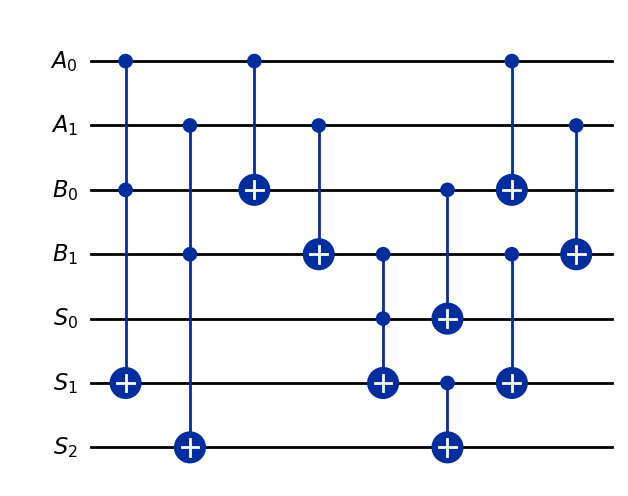

In [14]:
add_qc = QuantumCircuit(a, b, s, name="Prefix Tree Adder")
# Intial propagation and generation
for i in range(2):
    add_qc.ccx(a[i], b[i], s[i+1]) # g, it's in the next index in s
    add_qc.cx(a[i], b[i]) # p

# G
# G0 = g0
# G1 = g1 + p1 * g0
add_qc.ccx(s[0], b[1], s[1])
# but XOR ≠ OR
# this is what is instructed in the Wang paper
# TODO use ancillas to calculate OR or verify which one is correct
# a + b = (a xor b) xor ab

# P is not computed because it is unnecessary

# c
# c0 = 0, c1 = G0 = g0, c2 = G1 = g0
add_qc.cx(s[1], s[2])

# s
add_qc.cx(b[0], s[0])
add_qc.cx(b[1], s[1])
# last carry = last s

# uncompute p
for i in range(2):
    add_qc.cx(a[i], b[i])
    
add_qc.draw("mpl")

# Test

In [15]:
print_metrics(add_qc)

Size: 10
Toffoli count: 3
CZ count: 42
T count: 21
Depth: 6
Toffoli depth: 2
CZ depth: 26
T depth: 8
Width: 7
Algebraic connectivity: 1.014837756964402


In [16]:
test_circuit(
    add_qc,
    list(range(2**n)), a,
    list(range(2**n)), b,
    [a, b, s],
    lambda a, b: (a + b) % (2**(n+1)),
    (0, n+1)
)

Initial state: 0000000
Final state:   0000000
Initial state: 0000100
Final state:   0010100
Initial state: 0001000
Final state:   0101000
Initial state: 0001100
Final state:   0111100
Initial state: 0000001
Final state:   0010001
Initial state: 0000101
Final state:   1100101
Error: 1, 1: got 6, expected 2
Initial state: 0001001
Final state:   0111001
Initial state: 0001101
Final state:   1001101
Initial state: 0000010
Final state:   0100010
Initial state: 0000110
Final state:   0110110
Initial state: 0001010
Final state:   1001010
Initial state: 0001110
Final state:   1011110
Initial state: 0000011
Final state:   0110011
Initial state: 0000111
Final state:   1000111
Initial state: 0001011
Final state:   1011011
Initial state: 0001111
Final state:   0101111
Error: 3, 3: got 2, expected 6
Total wrongs: 2
Total tests: 16
  1, 1: got 6, expected 2
  3, 3: got 2, expected 6


# Run

00 + 00 = 000

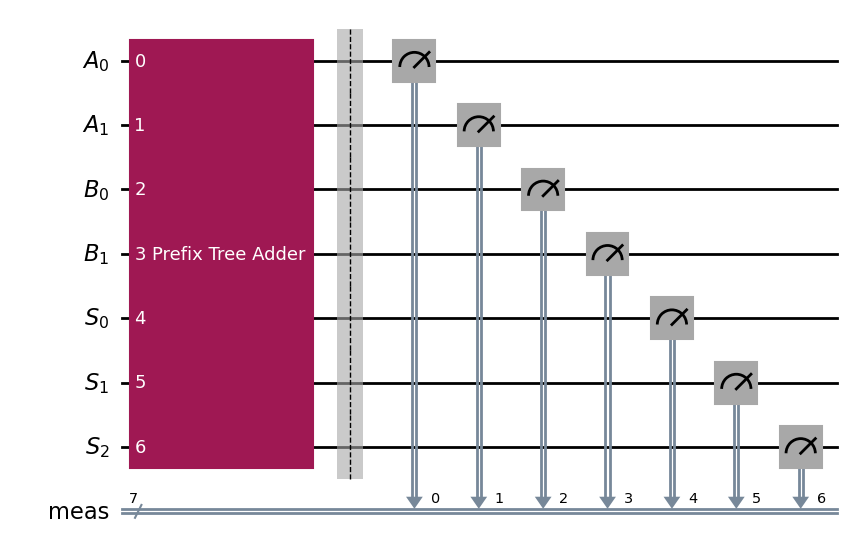

In [17]:
test_0 = QuantumCircuit(a, b, s)
test_0.append(add_qc, [*a, *b, *s])
test_0.measure_active()
test_0.draw("mpl")

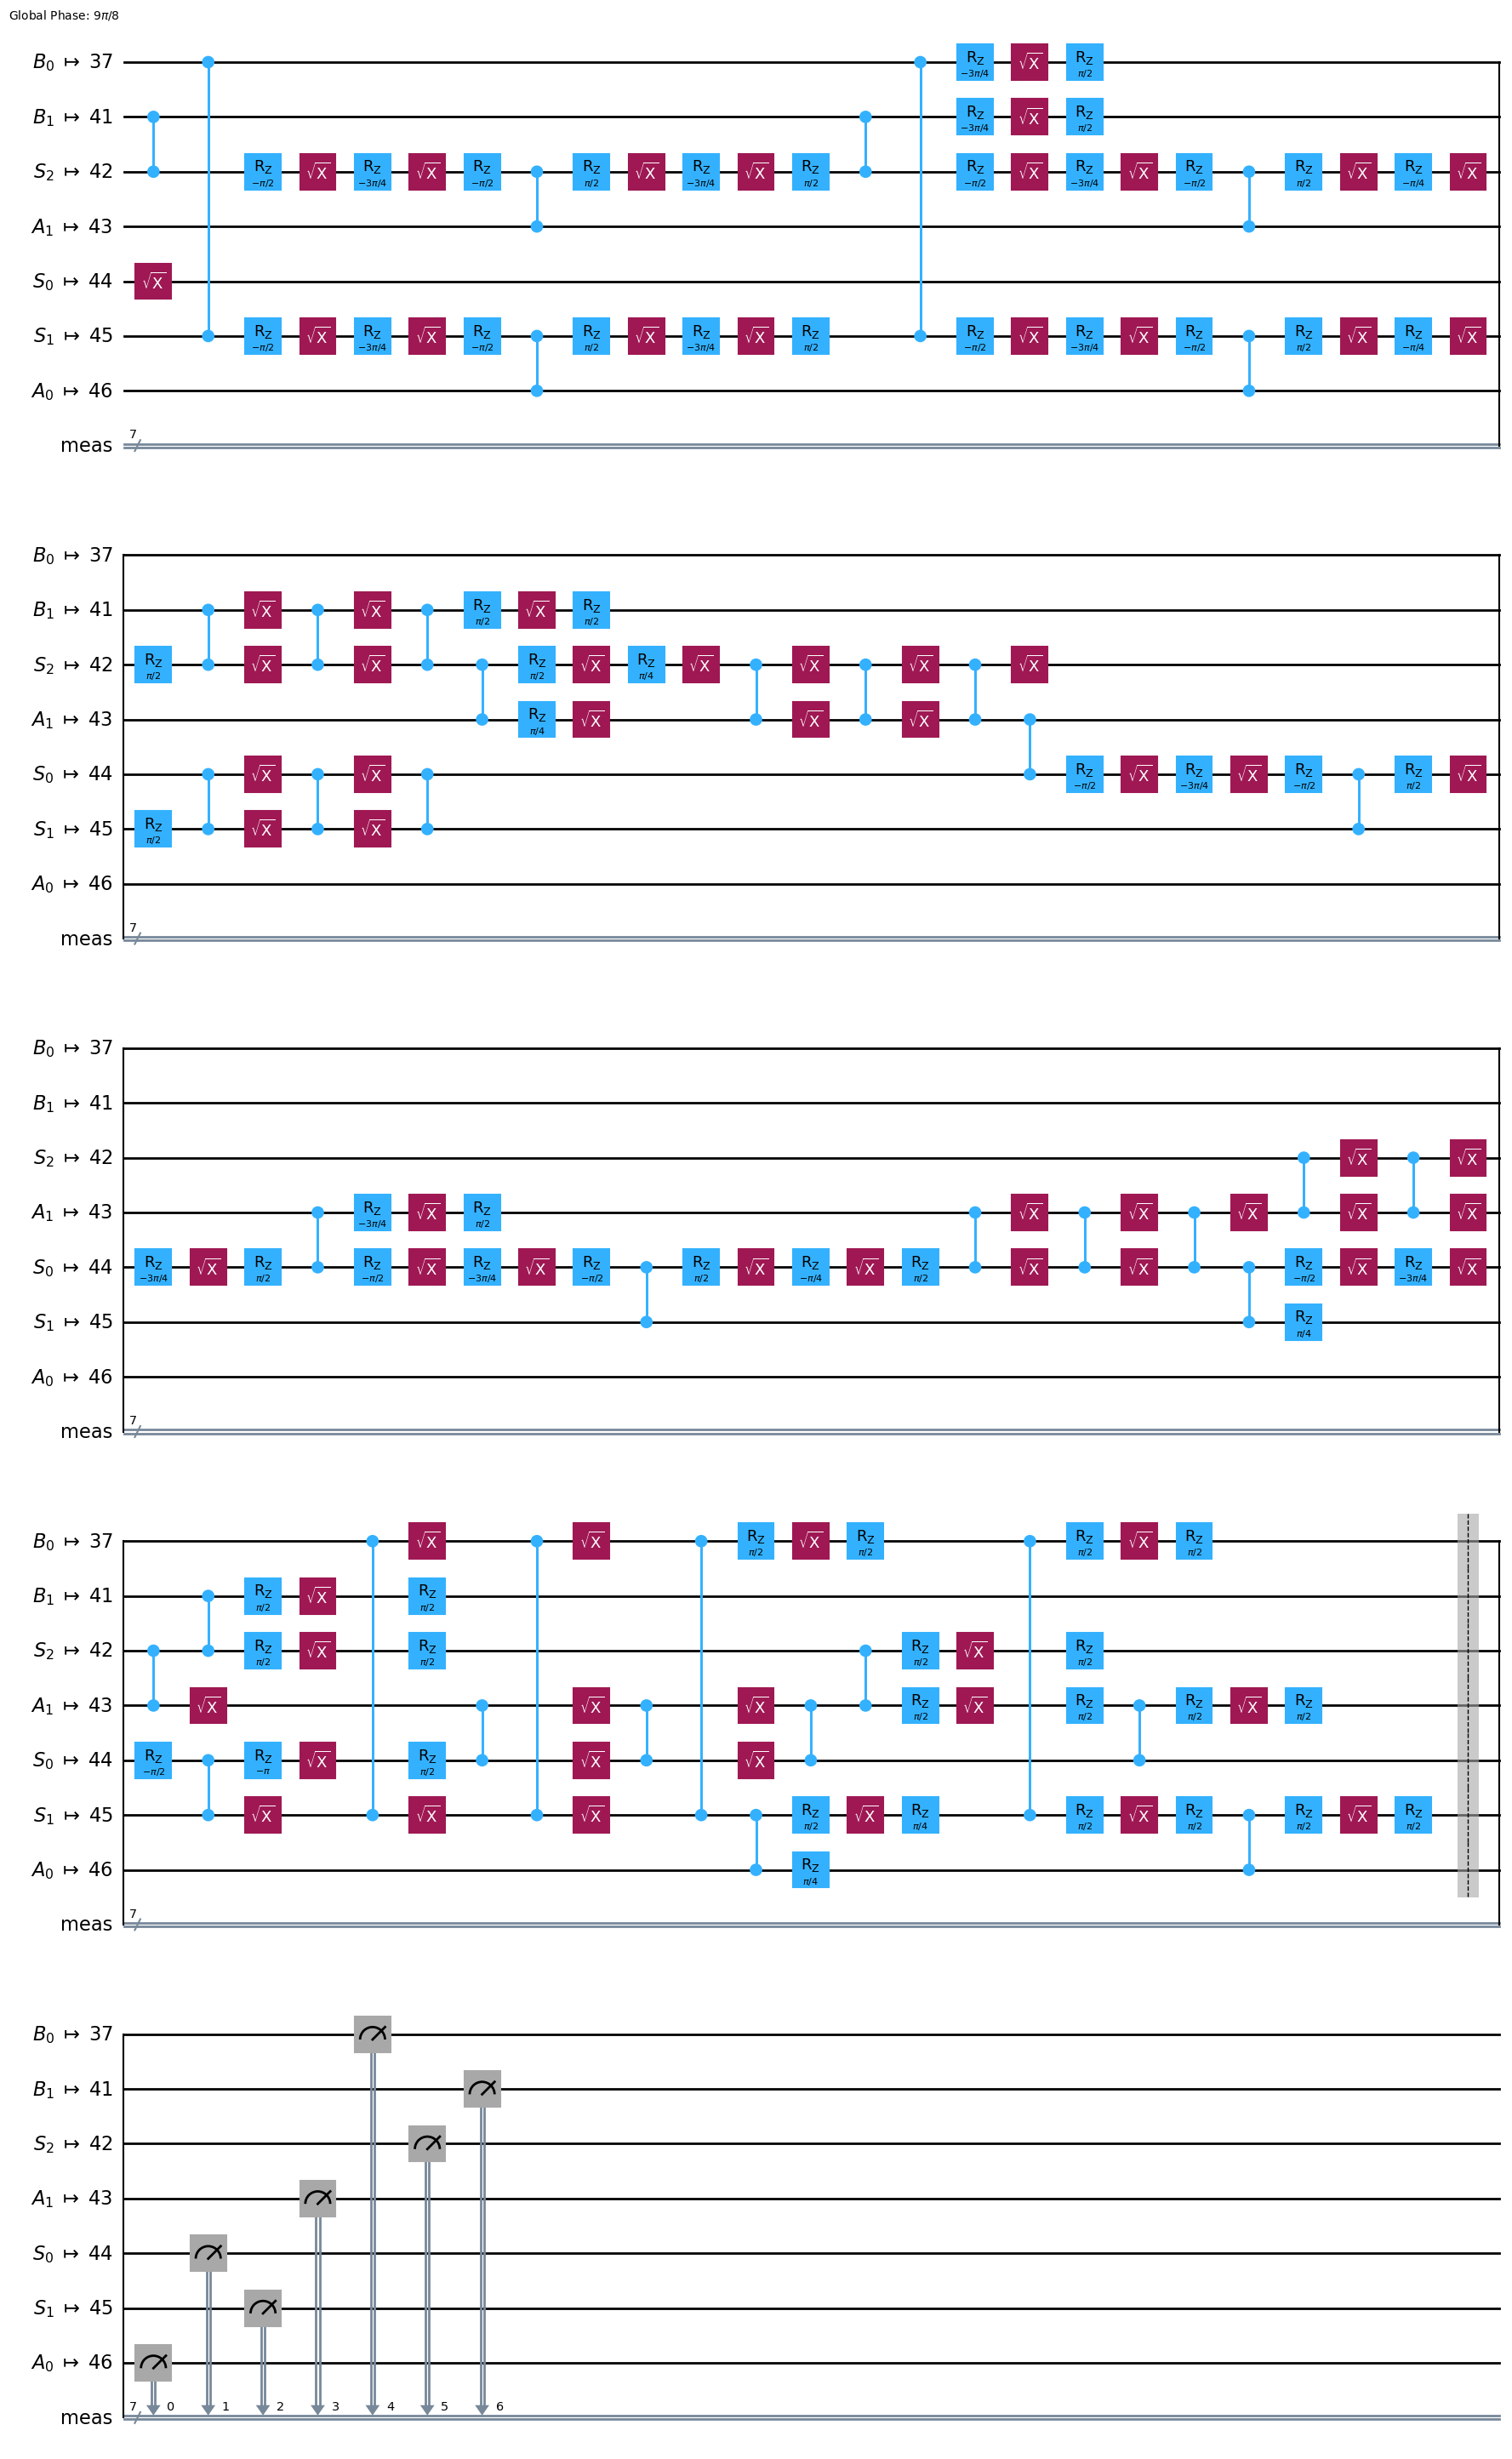

In [ ]:
isa_circ = pm.run(test_0)
isa_circ.draw("mpl")

In [20]:
backend_sampler.options.default_shots = 2**11
job = backend_sampler.run([isa_circ])
print(f"Job ID: {job.job_id()}")

Job ID: d9ah56rv6alc73crpbhg


Top 10 results:
{'0000000': 1652, '0101000': 63, '1000000': 52, '0010000': 44, '0001010': 33, '1100000': 30, '0000100': 24, '1101000': 22, '0010100': 19, '0001000': 17}
Number of keys: 41
Number of shots: 2048
Expected result 0000000: 1652
Probability: 0.8066


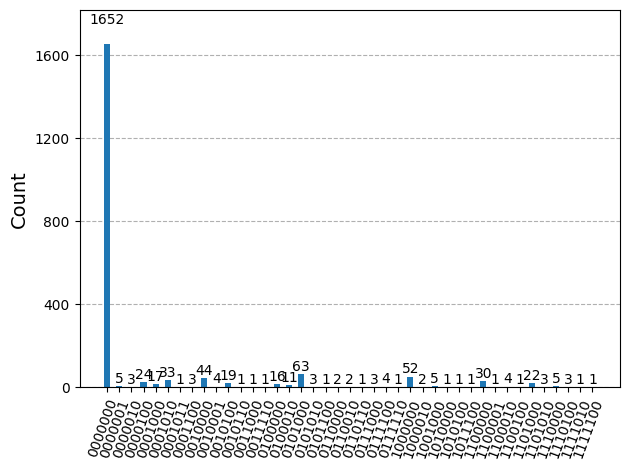

In [66]:
inspect_results(job, "0000000")

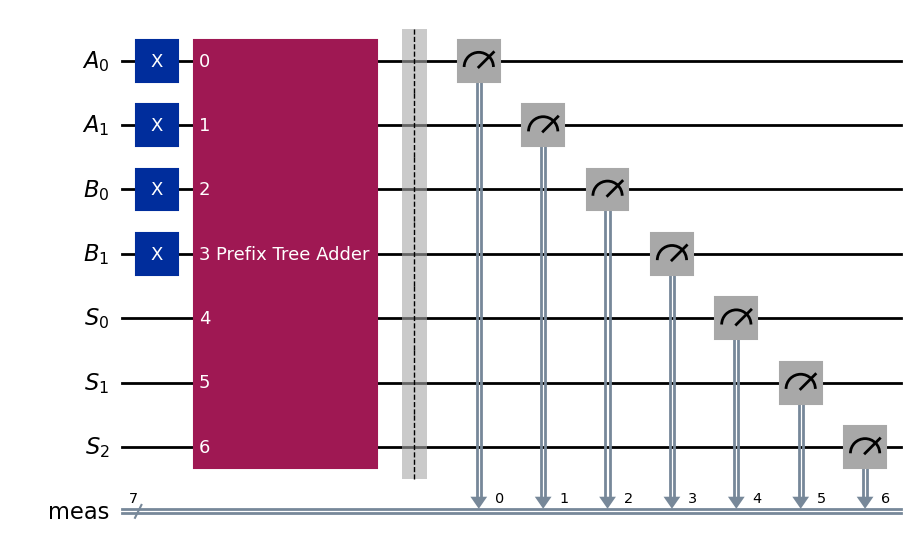

In [72]:
test_1 = QuantumCircuit(a, b, s)
for i in range(2):
    test_1.x(a[i])
    test_1.x(b[i])
test_1.append(add_qc, [*a, *b, *s])
test_1.measure_active()
test_1.draw("mpl")

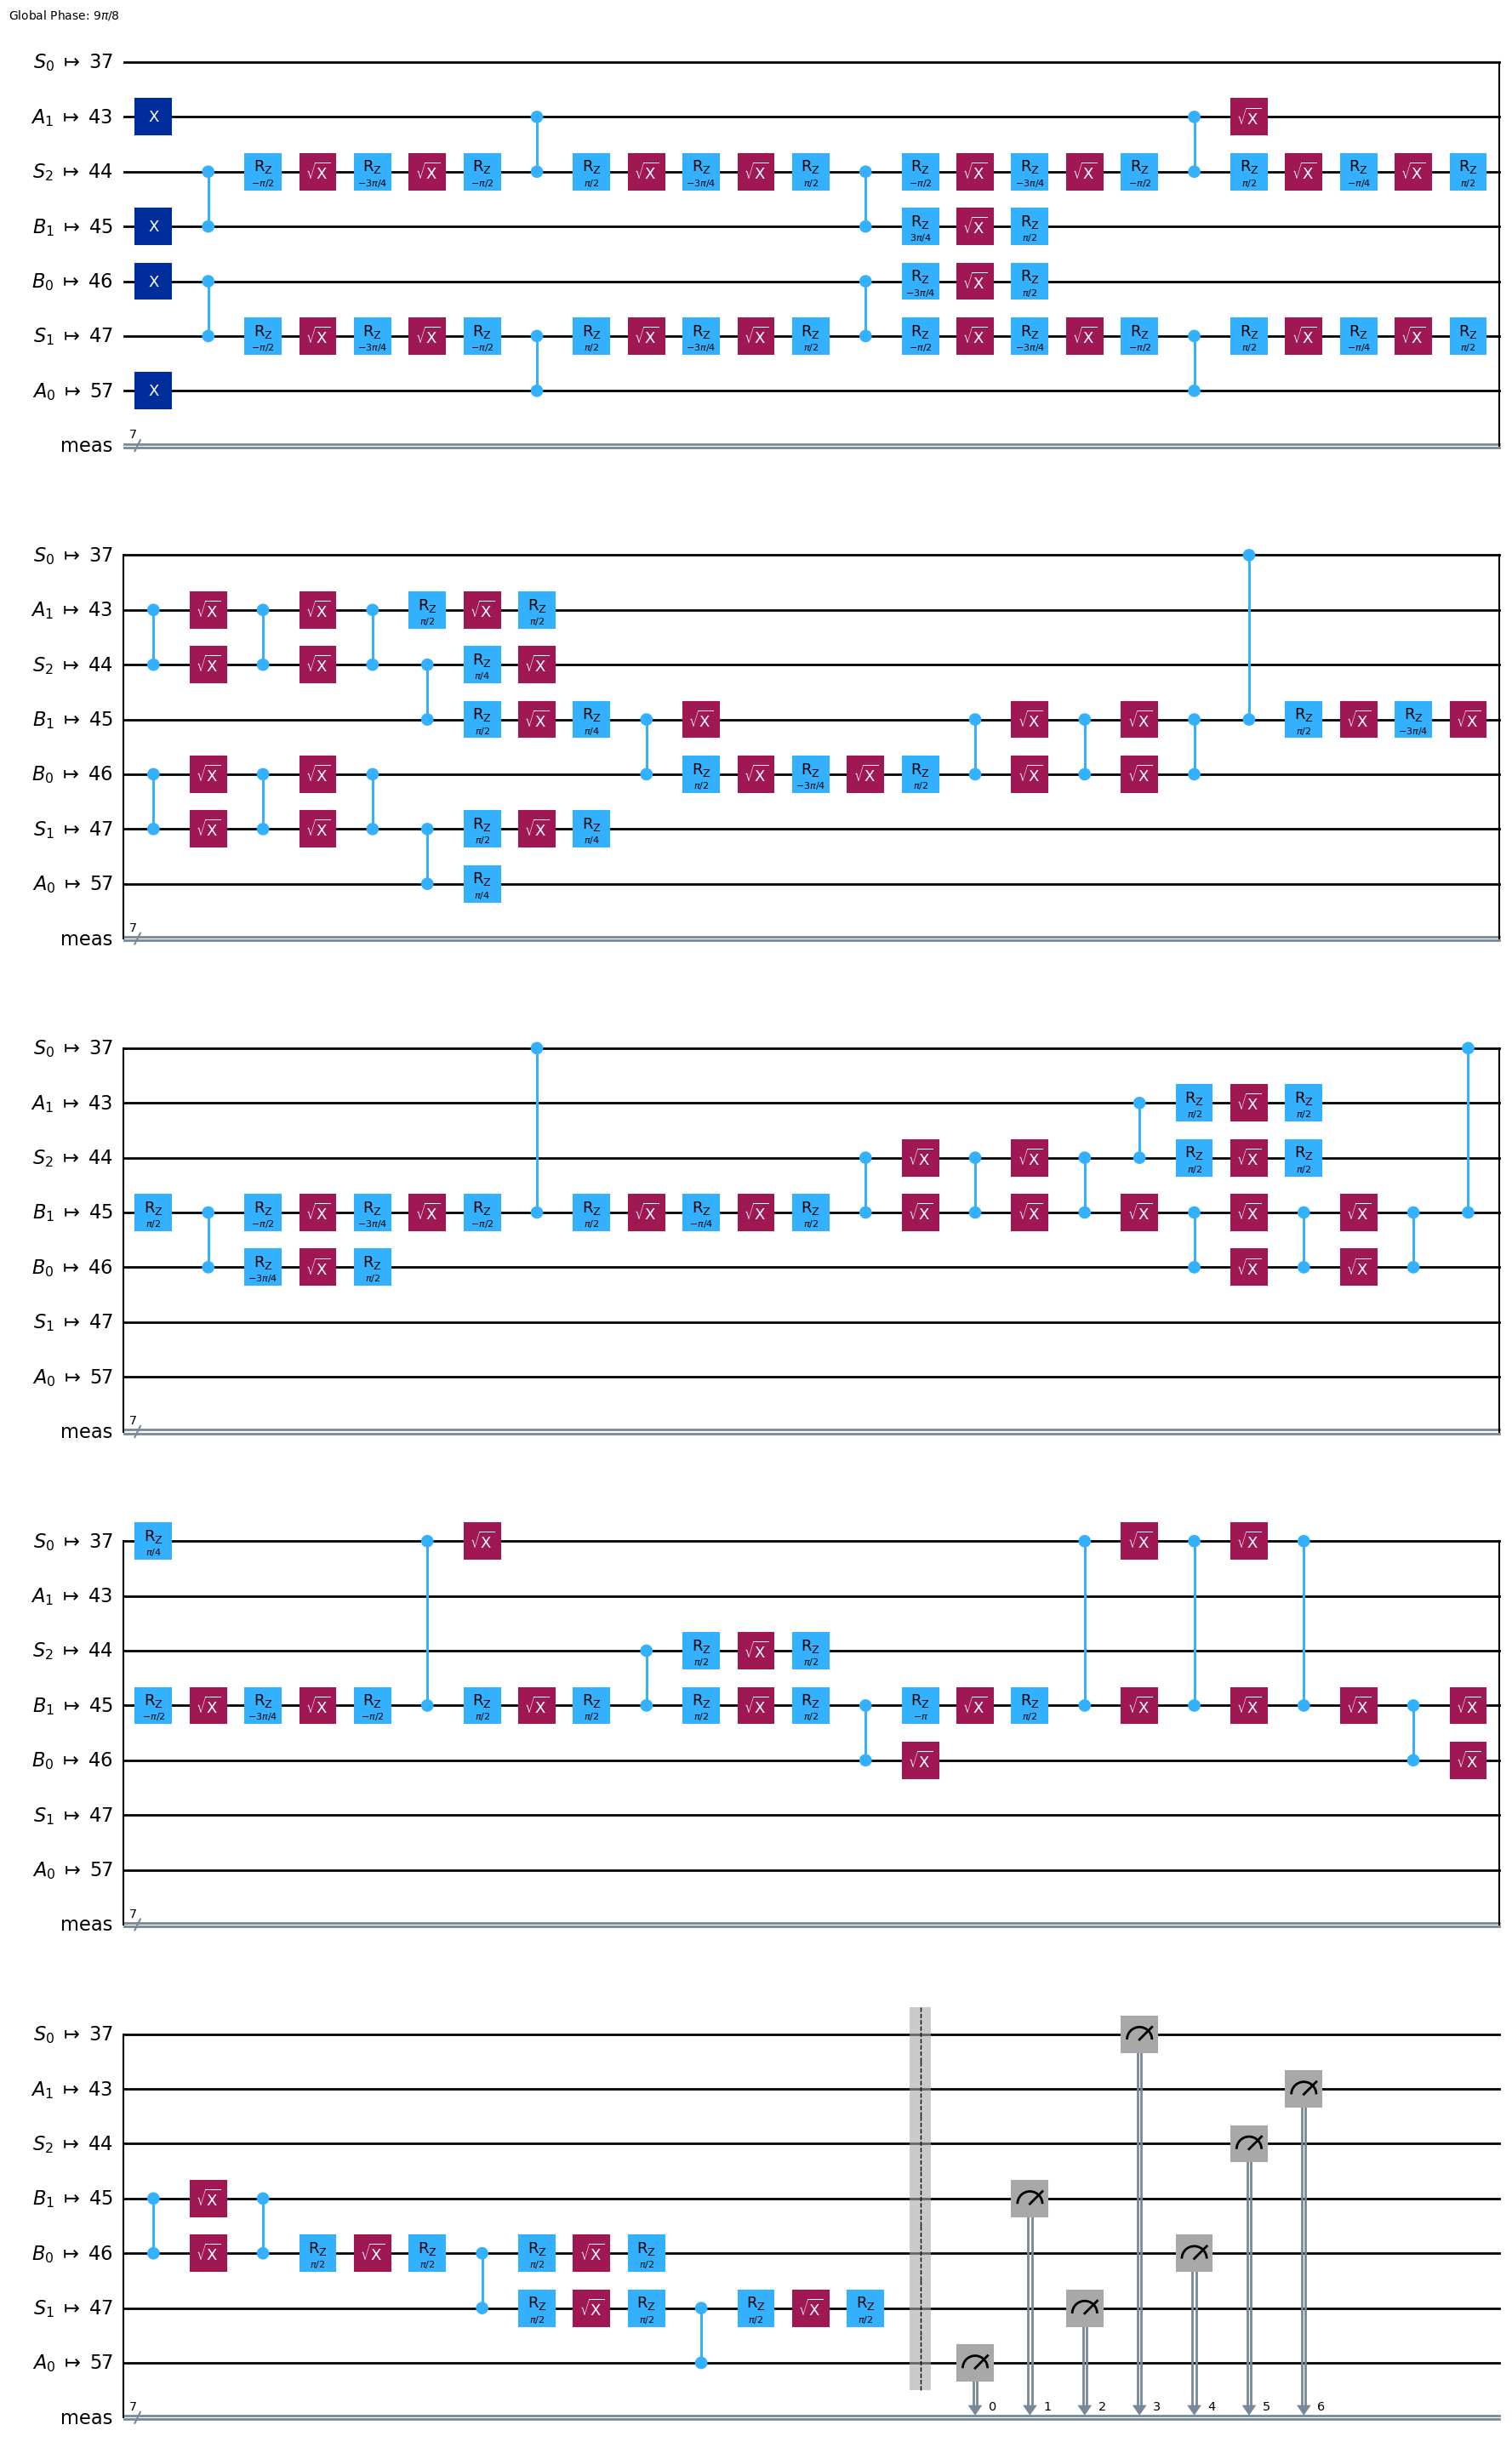

In [71]:
isa_circ = pm.run(test_1)
isa_circ.draw("mpl")

In [73]:
job = backend_sampler.run([isa_circ])
print(f"Job ID: {job.job_id()}")

Job ID: d9ahg6m6hjac73fee570


Top 10 results:
{'0101111': 2955, '1101111': 140, '1001111': 84, '0000111': 79, '0111110': 63, '0100101': 62, '0100111': 58, '0111011': 48, '0101101': 46, '0111111': 42}
Number of keys: 82
Number of shots: 4096
Expected result 0101111: 2955
Probability: 0.7214


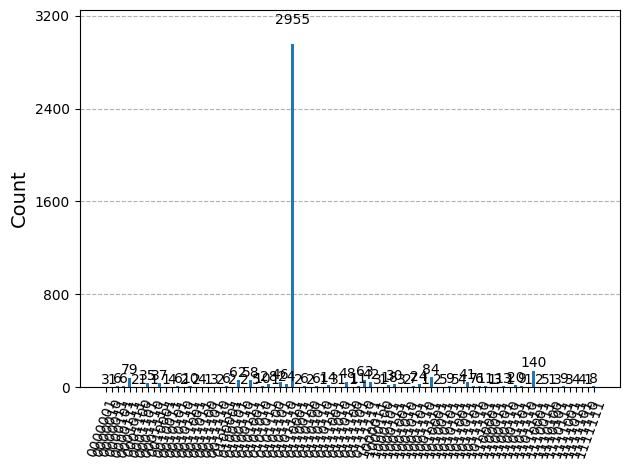

In [74]:
inspect_results(job, "0101111")  # dont ask